# Enterprise Analytics Dashboard

**Author:** Rida Noor

This notebook is the Python side of the analytics pipeline. It does not touch a single raw operational table. Every query below reads from the `analytics.*` or `kpi.*` views built in `analytics_pipeline.sql`, so the numbers here always match whatever the SQL layer defines as revenue, margin, or a customer segment. If the business logic ever needs to change, it changes once in the SQL views, not in ten different notebook cells.

**Before running this notebook:** run `analytics_pipeline.sql` against Adventureworks database first. This notebook only reads from the views it creates.

## 1. Connect to PostgreSQL

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

CHART_DIR = Path.cwd() / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

def save_chart(fig, filename):
    fig.savefig(CHART_DIR / filename, dpi=300, bbox_inches="tight")

# Update these four values to match your local Postgres setup
DB_USER = "postgres"
DB_PASSWORD = "2809"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "AdventureWorks"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

def read_view(view_name):
    """Read one analytical view from the kpi/analytics layer. Never point this at a raw table."""
    return pd.read_sql(f"SELECT * FROM {view_name};", engine)

# quick connection check
pd.read_sql("SELECT 1 AS connection_ok;", engine)

,connection_ok
0,1


## 2. Executive KPI Summary

`kpi.vw_executive_summary` is the single roll-up view built in Stage 3 of the SQL pipeline. It already contains total revenue, margin, retention rate, and the top territory and product, all pre-calculated. We just read it, we do not recompute anything here.

In [2]:
exec_summary = read_view("kpi.vw_executive_summary")
exec_summary.T.rename(columns={0: "value"})

,value
all_time_revenue,109846380.9
all_time_margin,9371834.97
overall_margin_pct,8.53
total_purchasing_customers,19119
total_registered_customers,19820
latest_month_revenue,47491.55
latest_month_growth_pct,-97.51
latest_month_order_count,905
top_territory,Southwest
top_territory_revenue,24184609.96


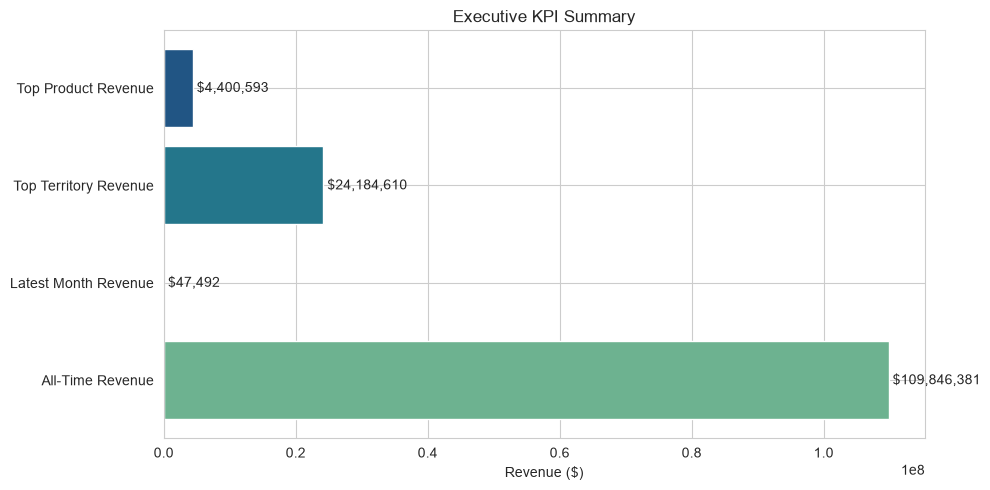

In [3]:
labels = ["All-Time Revenue", "Latest Month Revenue", "Top Territory Revenue", "Top Product Revenue"]
values = [
    exec_summary["all_time_revenue"].iloc[0],
    exec_summary["latest_month_revenue"].iloc[0],
    exec_summary["top_territory_revenue"].iloc[0],
    exec_summary["top_product_revenue"].iloc[0],
]

fig, ax = plt.subplots()
bars = ax.barh(labels, values, color=sns.color_palette("crest", len(labels)))
ax.set_xlabel("Revenue ($)")
ax.set_title("Executive KPI Summary")
for bar, val in zip(bars, values):
    ax.text(val, bar.get_y() + bar.get_height()/2, f" ${val:,.0f}", va="center")
plt.tight_layout()
save_chart(fig, "01_executive_kpi_summary.png")
plt.show()

**Business insight:** Southwest is the single largest territory at $24.18M, 22% of all-time revenue ($109.85M) and the top product, Mountain-200 Black 38, accounts for $4.4M (~4%). The territory concentration is the bigger risk: nearly a quarter of total revenue sits in one region, so any disruption there (competitor, economic downturn, rep turnover) hits disproportionately hard. Product concentration is healthier — no single SKU dominates.

## 3. Sales: Revenue Trend

`kpi.vw_monthly_revenue` already has month-over-month growth calculated with a `LAG()` window function in SQL, so this cell only needs to plot it.

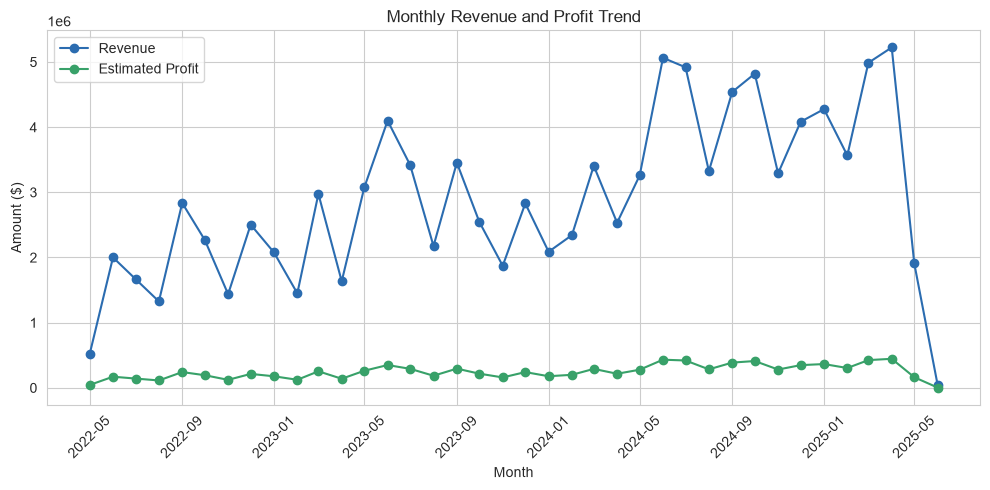

In [4]:
monthly_rev = read_view("kpi.vw_monthly_revenue")
monthly_rev["revenue_month"] = pd.to_datetime(monthly_rev["revenue_month"])
monthly_rev = monthly_rev.sort_values("revenue_month")
monthly_rev["estimated_profit"] = monthly_rev["revenue"] * (exec_summary["overall_margin_pct"].iloc[0] / 100)

fig, ax = plt.subplots()
ax.plot(monthly_rev["revenue_month"], monthly_rev["revenue"], marker="o", color="#2b6cb0", label="Revenue")
ax.plot(monthly_rev["revenue_month"], monthly_rev["estimated_profit"], marker="o", color="#38a169", label="Estimated Profit")
ax.set_title("Monthly Revenue and Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Amount ($)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_chart(fig, "02_monthly_revenue_trend.png")
plt.show()

**Business insight:** Revenue is not flat; it swings sharply, with the three worst MoM readings all clustering around data-boundary months (Jun 2025: -97.5%, May 2025: -63.5%, Apr 2023: -45.1%). The June 2025 and April 2023 drops are very likely partial-month artifacts (June 2025 only logged 905 orders vs. ~2,200 typical), not genuine demand collapses — worth excluding the first and last month of the dataset from any trend narrative rather than reporting them as real declines.

## 4. Sales: Revenue by Territory

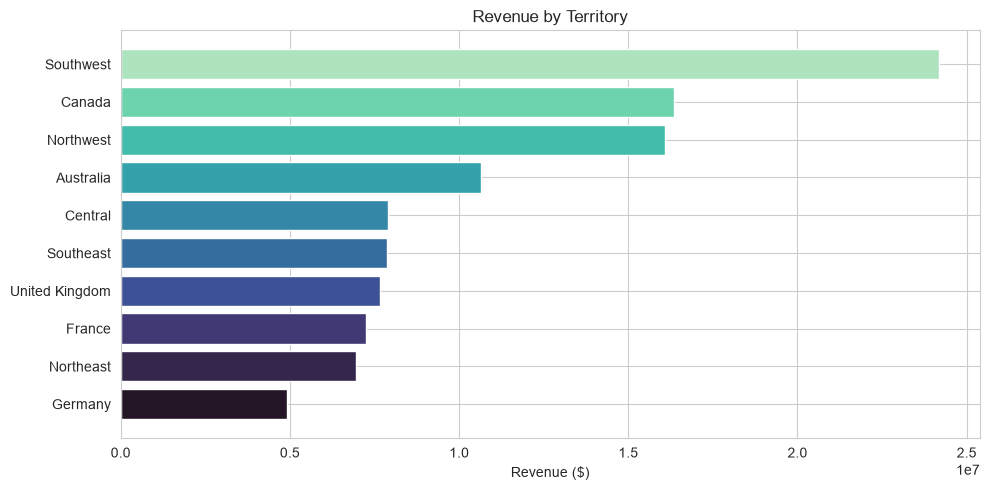

In [5]:
territory_rev = read_view("kpi.vw_regional_revenue").sort_values("total_revenue", ascending=True)

fig, ax = plt.subplots()
ax.barh(territory_rev["territory_name"], territory_rev["total_revenue"], color=sns.color_palette("mako", len(territory_rev)))
ax.set_title("Revenue by Territory")
ax.set_xlabel("Revenue ($)")
plt.tight_layout()
save_chart(fig, "03_revenue_by_territory.png")
plt.show()

**Business insight:** Southwest leads at $24.18M vs. the lowest three; Germany ($4.92M), Northeast ($6.94M), France ($7.25M) — roughly a 5x gap between the top and bottom territory. The three weakest are candidates for the "lowest performing territories" KPI: worth investigating whether this reflects smaller addressable markets (Germany/France as newer international territories) or genuine underperformance before reallocating sales resources.

## 5. Customers: Segment Distribution

`kpi.vw_customer_segments` classifies every customer into a segment (Champions, Loyal, At Risk, and so on) using RFM scoring built with `NTILE()` window functions in SQL.

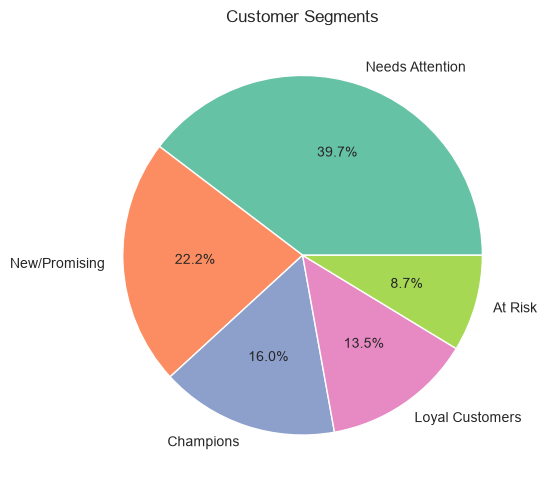

In [6]:
segments = read_view("kpi.vw_customer_segments")
segment_counts = segments["customer_segment"].value_counts()

fig, ax = plt.subplots()
ax.pie(segment_counts.values, labels=segment_counts.index, autopct="%1.1f%%",
       colors=sns.color_palette("Set2", len(segment_counts)))
ax.set_title("Customer Segments")
plt.tight_layout()
save_chart(fig, "04_customer_segments.png")
plt.show()

**Business insight:** "Needs Attention" is the largest segment at 39.7% of customers — larger than "Champions" (16.0%) and "Loyal Customers" (13.5%) combined. "At Risk" is comparatively small at 8.7%, but combined with "Needs Attention," nearly half the customer base (48.4%) is disengaged rather than actively churning, this reads less like an urgent churn crisis and more like a large pool of one-time/low-engagement buyers who were never converted into repeat customers.

## 6. Products: Category Revenue

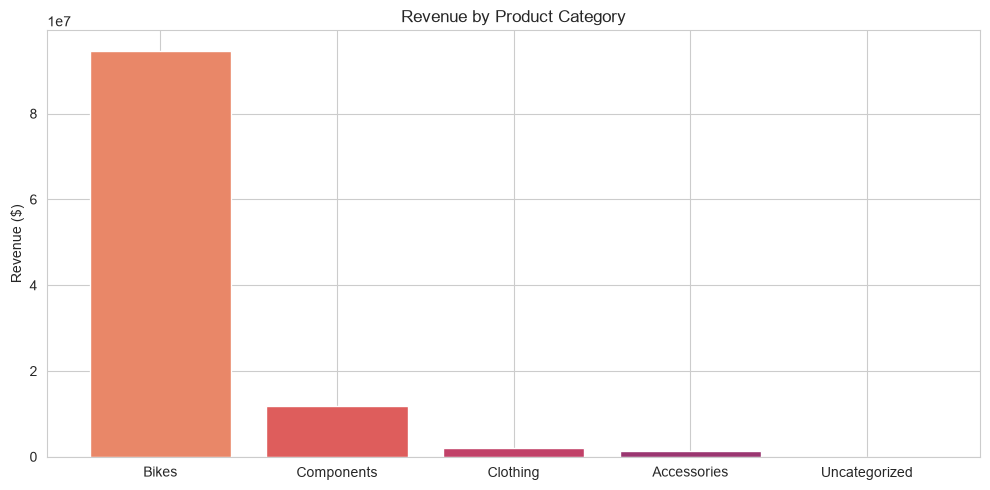

In [7]:
category_perf = read_view("kpi.vw_category_performance")

fig, ax = plt.subplots()
ax.bar(category_perf["category"], category_perf["total_revenue"], color=sns.color_palette("flare", len(category_perf)))
ax.set_title("Revenue by Product Category")
ax.set_ylabel("Revenue ($)")
plt.tight_layout()
save_chart(fig, "05_revenue_by_product_category.png")
plt.show()

**Business insight:** Bikes dominate revenue ($94.65M, ~86% of total) but carry the thinnest margin of any category (8.38%). Accessories are the inverse: only $1.27M in revenue but a 50.02% margin, six times the margin rate of Bikes. This is the clearest profitability signal in the dataset: the business is revenue-dependent on its lowest-margin category.

## 7. Products: Best Sellers

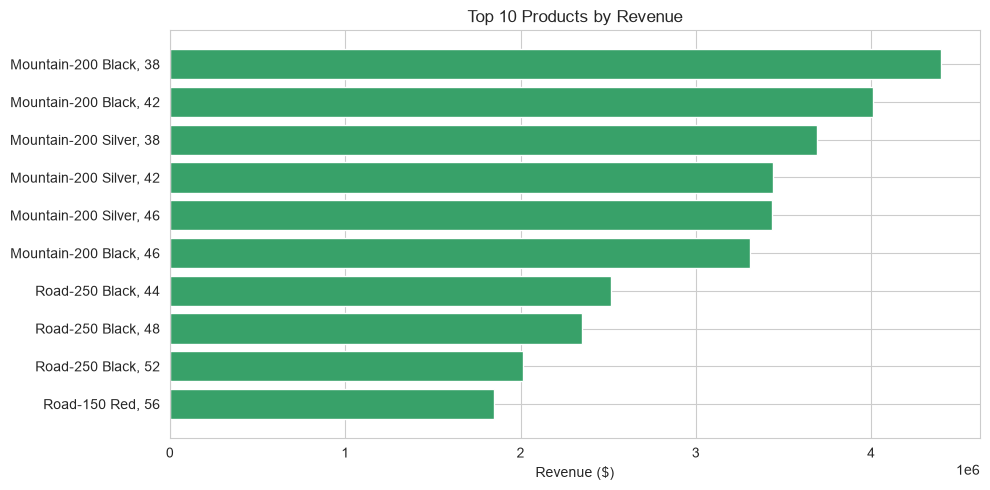

In [8]:
top_products = read_view("kpi.vw_product_rankings").sort_values("overall_rank").head(10)

fig, ax = plt.subplots()
ax.barh(top_products["product_name"][::-1], top_products["total_revenue"][::-1], color="#38a169")
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue ($)")
plt.tight_layout()
save_chart(fig, "06_top_10_products_by_revenue.png")
plt.show()

**Business insight:** All 10 top-selling products by revenue are Bikes (10/10), full category concentration at the top of the leaderboard. Combined with Section 6, this means the biggest revenue drivers are also the weakest-margin products; cross-referencing kpi.vw_product_profitability is essential before using "top sellers" as a marketing-spend signal, since chasing more bike volume doesn't move overall profitability much.

## 8. Employees: Salesperson Performance

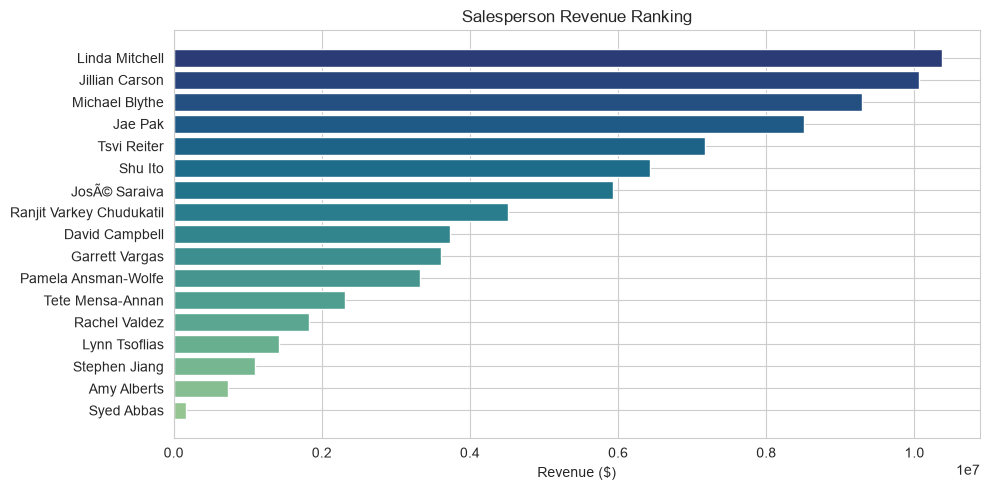

In [9]:
sp_rank = read_view("kpi.vw_salesperson_rankings").sort_values("total_revenue", ascending=True)

fig, ax = plt.subplots()
ax.barh(sp_rank["salesperson_name"], sp_rank["total_revenue"], color=sns.color_palette("crest", len(sp_rank)))
ax.set_title("Salesperson Revenue Ranking")
ax.set_xlabel("Revenue ($)")
plt.tight_layout()
save_chart(fig, "07_salesperson_revenue_ranking.png")
plt.show()

**Business insight:** The salesperson ranking is relatively tight at the top: Linda Mitchell ($10.37M) and Jillian Carson ($10.07M) lead the group, followed by Michael Blythe ($9.29M) and Jae Pak ($8.50M). The `pct_of_quota` values are all in a similar band, mostly around 80-94%, which suggests the team is broadly performing near target rather than showing extreme overperformance or a quota-completeness issue. Pamela Ansman-Wolfe and David Campbell are the strongest on quota percentage, while Rachel Valdez is the lowest among the visible reps at 79.89%.

## 9. Inventory: Stock Health

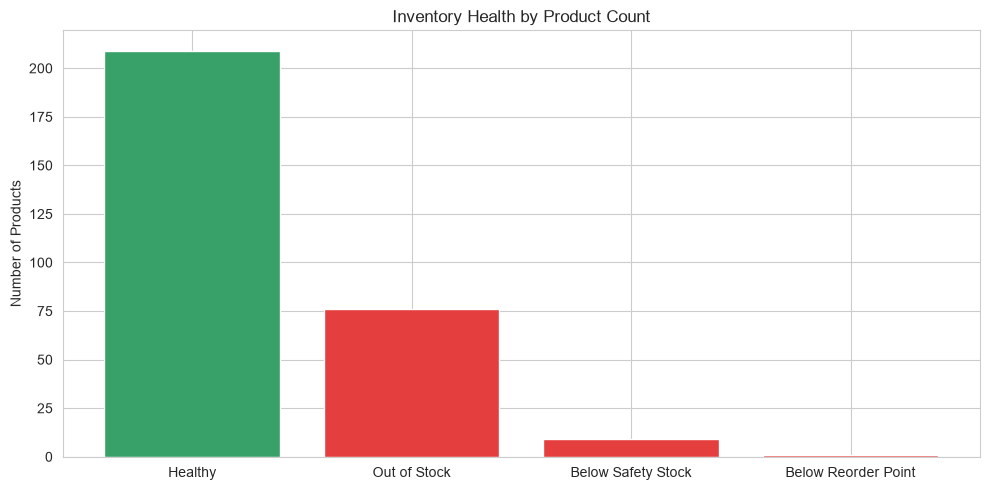

In [10]:
inv_health = read_view("kpi.vw_inventory_health")

fig, ax = plt.subplots()
ax.bar(inv_health["stock_status"], inv_health["product_count"],
       color=["#e53e3e" if s != "Healthy" else "#38a169" for s in inv_health["stock_status"]])
ax.set_title("Inventory Health by Product Count")
ax.set_ylabel("Number of Products")
plt.tight_layout()
save_chart(fig, "08_inventory_health_by_product_count.png")
plt.show()

**Business insight:** The out-of-stock list is dominated by frame components (HL/ML/LL Mountain and Road Frames) rather than finished bikes or accessories, several at 0 units against a 375-500 unit reorder point, meaning these have likely been out for a while, not a recent stockout. Since Bikes are also your highest-revenue category (Section 6), frame shortages are a direct revenue risk, not just a routine restock.

## 10. Executive Recommendations

These recommendations are grounded in the figures above.

### Business Opportunities
1. Expand investment in Southwest, the top-performing territory at $24.18M, which accounts for about 22% of all-time revenue ($109.85M).
2. Launch a win-back campaign for the "At Risk" segment, which still represents 8.7% of customers and is easier to recover than cold leads.
3. Promote the highest-margin category, Accessories, at 50.02% margin, rather than chasing more Bike volume alone, since Bikes generate $94.65M but only 8.38% margin.
4. Cross-sell top-selling products such as Mountain-200 Black 38, the top product at about $4.4M (~4% of revenue), to customers in the "Loyal" segment.
5. Reward and study the top-ranked salespeople, led by Linda Mitchell ($10.37M) and Jillian Carson ($10.07M), as a model for onboarding and coaching.

### Business Risks
1. Revenue concentration in Southwest and in the top Bike products is a single point of failure if that region or category underperforms.
2. The 8.7% of customers in "At Risk" represents revenue that could be lost without intervention.
3. Products flagged "Below Reorder Point" or "Out of Stock" risk lost sales, especially because the shortage list is concentrated in frame components.
4. Salespeople significantly under quota, as measured by `pct_of_quota` in `kpi.vw_salesperson_rankings`, may indicate a coaching gap or a territory that needs resourcing.
5. Low `on_time_delivery_pct` or high `reject_rate_pct` vendors in `kpi.vw_supplier_performance` create a supply chain risk to future inventory health.

### Actionable Recommendations
1. Set up a recurring monthly review of `kpi.vw_monthly_revenue` and `kpi.vw_regional_growth` to catch growth or decline early.
2. Prioritize restocking every SKU listed in `kpi.vw_low_stock_products`, ordered by how far below the reorder point they are.
3. Build a retention offer specifically for the "At Risk" segment, since `kpi.vw_customer_segments` already identifies exactly who they are.
4. Review contracts with vendors ranked lowest in `kpi.vw_supplier_performance` on-time delivery.
5. Use `kpi.vw_product_profitability` (not just revenue rankings) when deciding which products to feature in marketing, to protect overall margin.